# COSMIC-LATENT
## Governed Exploratory AI Methods for Multisource Cosmological Representation Spaces

Name: Sabrina Palis

Repository: https://github.com/MinervaRose/cosmic-latent-governance

### Notebook 1 — Methods and Governance

This notebook explores whether heterogeneous cosmological datasets can be embedded into partially coherent shared representation spaces using governed AI methods.

The notebook focuses on:
- multisource representation learning,
- information geometry,
- topology-aware analysis,
- anomaly discovery,
- and epistemic governance under uncertainty.

This notebook does not attempt to claim physical discovery.
Its purpose is exploratory computational systems research.

Interpretive speculation is intentionally separated into Notebook 2.


## Coordinate and Representation Disclaimer

The coordinate systems used here are intentionally normalized and partially abstracted.

The notebook therefore studies organizational structure in representation space rather than making direct claims about physical cosmological geometry.

Cross-dataset normalization is used to enable comparative analysis between:
- observational catalogues,
- morphology-derived features,
- and cosmological simulations.


# COSMIC-LATENT
## Governed AI Exploration of Informational Order in Dark Matter Proxies

**Research question:** Can information-theoretic and topological AI methods detect emergent organizational structure in cosmological datasets beyond conventional spatial clustering metrics?

Datasets: **SDSS**, **Euclid Q1 local CSV**, **IllustrisTNG API**, **Galaxy Zoo**, and optional **strong-lensing** catalogue/image hooks.

This notebook does not claim new dark matter physics. It builds a governed exploratory AI pipeline for cosmological proxy structure under uncertainty.


In [1]:
import os, sys, warnings, subprocess, importlib.util
warnings.filterwarnings('ignore')

def pip_install(pkg, imp=None):
    imp = imp or pkg.replace('-', '_')
    if importlib.util.find_spec(imp) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for pkg, imp in [('astropy','astropy'),('astroquery','astroquery'),('scikit-learn','sklearn'),('plotly','plotly'),('networkx','networkx')]:
    pip_install(pkg, imp)
try:
    import umap; HAS_UMAP=True
except Exception:
    try:
        pip_install('umap-learn','umap'); import umap; HAS_UMAP=True
    except Exception: HAS_UMAP=False
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TF=True
except Exception: HAS_TF=False
try:
    from ripser import ripser
    from persim import plot_diagrams
    HAS_TDA=True
except Exception:
    try:
        pip_install('ripser','ripser'); pip_install('persim','persim')
        from ripser import ripser; from persim import plot_diagrams; HAS_TDA=True
    except Exception: HAS_TDA=False

import numpy as np, pandas as pd, requests, networkx as nx, matplotlib.pyplot as plt
import plotly.express as px, plotly.graph_objects as go
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import SpectralEmbedding
from sklearn.ensemble import IsolationForest
SEED=42; np.random.seed(SEED)
print('UMAP',HAS_UMAP,'TF',HAS_TF,'TDA',HAS_TDA)


UMAP True TF True TDA True


In [24]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.8 MB/s eta 0:00:00


## Configuration
Set your Euclid CSV path and TNG API key. Prefer Colab Secrets for the key (`TNG_API_KEY`).

**Rerun safety note:** this notebook merges Galaxy Zoo only once, after `cosmic_df` is built. It also treats missing Euclid quality probabilities as neutral instead of penalizing SDSS/TNG rows.


In [2]:
EUCLID_CSV_PATH = '/content/1a0cbce5-5836-11f1-a9b1-e8ebd3edb7d7-TPDR-result.csv'
SDSS_ROW_LIMIT = 2000
TNG_API_KEY = None
try:
    from google.colab import userdata
    TNG_API_KEY = userdata.get('TNG_API_KEY')
except Exception:
    pass
TNG_SIM='TNG100-1'; TNG_SNAPSHOT=99; TNG_DETAIL_LIMIT=250
ENABLE_GALAXY_ZOO=True; ENABLE_LENSING_CANDIDATES=True


# Module 1 — Cosmological data ingestion

In [3]:
def load_sdss_sample(row_limit=2000):
    try:
        from astroquery.sdss import SDSS
        query = (
            'SELECT TOP %d p.objid, p.ra, p.dec, s.z AS redshift, '
            'p.u, p.g, p.r, p.i, p.z AS zmag '
            'FROM PhotoObj AS p JOIN SpecObj AS s ON s.bestobjid = p.objid '
            "WHERE p.type = 3 AND s.class = 'GALAXY' AND s.z BETWEEN 0.02 AND 0.30 "
            'AND p.clean = 1 AND p.u BETWEEN 0 AND 30 AND p.g BETWEEN 0 AND 30 '
            'AND p.r BETWEEN 0 AND 30 AND p.i BETWEEN 0 AND 30 AND p.z BETWEEN 0 AND 30'
        ) % row_limit
        result = SDSS.query_sql(query, data_release=17)
        return result.to_pandas() if result is not None else pd.DataFrame()
    except Exception as e:
        print('SDSS query failed:', repr(e)); return pd.DataFrame()

def process_sdss(raw):
    if raw is None or len(raw)==0: return pd.DataFrame()
    df=raw.copy(); df.columns=[c.strip().lower() for c in df.columns]
    req=['ra','dec','redshift','u','g','r','i','zmag']
    for c in req: df[c]=pd.to_numeric(df[c],errors='coerce')
    df=df.dropna(subset=req).reset_index(drop=True)
    D=cosmo.comoving_distance(df['redshift'].values).to(u.Mpc).value
    ra=np.deg2rad(df['ra'].values); dec=np.deg2rad(df['dec'].values)
    df['x']=D*np.cos(dec)*np.cos(ra); df['y']=D*np.cos(dec)*np.sin(ra); df['z']=D*np.sin(dec)
    df['u_g']=df['u']-df['g']; df['g_r']=df['g']-df['r']; df['r_i']=df['r']-df['i']; df['i_z']=df['i']-df['zmag']
    df['source_label']='SDSS_DR17_spectroscopic_galaxy'; df['data_channel']='observational_catalogue'
    return df

sdss_raw=load_sdss_sample(SDSS_ROW_LIMIT); sdss_processed=process_sdss(sdss_raw)
print('SDSS raw/processed:', sdss_raw.shape, sdss_processed.shape); display(sdss_processed.head())


SDSS raw/processed: (2000, 9) (2000, 18)


,objid,ra,dec,redshift,u,g,r,i,zmag,x,y,z,u_g,g_r,r_i,i_z,source_label,data_channel
0,1237648703509102769,196.554898,-0.664147,0.083987,19.00659,17.46996,16.69207,16.29661,16.01036,-349.590818,-103.917974,-4.227733,1.53663,0.77789,0.39546,0.28625,SDSS_DR17_spectroscopic_galaxy,observational_catalogue
1,1237648703509102787,196.591389,-0.827959,0.190357,20.55509,18.50240,17.25141,16.77685,16.43557,-771.305055,-229.809809,-11.630844,2.05269,1.25099,0.47456,0.34128,SDSS_DR17_spectroscopic_galaxy,observational_catalogue
2,1237648703509102812,196.612641,-0.806041,0.084177,18.73435,16.83528,15.89845,15.49562,15.14348,-350.248702,-104.497822,-5.142289,1.89907,0.93683,0.40283,0.35214,SDSS_DR17_spectroscopic_galaxy,observational_catalogue
3,1237648703509102821,196.623459,-0.797385,0.084211,19.27567,17.23888,16.27929,15.86932,15.52172,-350.367110,-104.605193,-5.089068,2.03679,0.95959,0.40997,0.34760,SDSS_DR17_spectroscopic_galaxy,observational_catalogue
4,1237648703516770428,214.120630,-0.743875,0.048742,17.08624,15.41548,14.67285,14.25464,13.94828,-176.724747,-119.744473,-2.771681,1.67076,0.74263,0.41821,0.30636,SDSS_DR17_spectroscopic_galaxy,observational_catalogue


## SDSS Representation-Space Construction

The SDSS subset provides the observational foundation of the multisource representation space.

For each galaxy, celestial coordinates and redshift are transformed into an approximate three-dimensional proxy coordinate system. This transformation is intentionally simplified and is used for exploratory organizational analysis rather than precision cosmology.

Additional colour-index features (`u-g`, `g-r`, `r-i`, `i-z`) are derived from SDSS photometric bands. These colour relationships often encode information related to:
- stellar population composition,
- galaxy morphology,
- star formation history,
- and observational structure.

The purpose of this stage is therefore not direct astrophysical interpretation, but the construction of a coherent high-dimensional feature representation suitable for:
- manifold learning,
- topology-aware analysis,
- anomaly detection,
- and cross-dataset comparison.

At this stage, the notebook establishes the observational component of the shared representation space that will later be integrated with:
- Euclid morphology-rich catalogues,
- Galaxy Zoo human-labelled morphology signals,
- and IllustrisTNG cosmological simulations.

In [4]:
def load_euclid_csv(path):
    if not os.path.exists(path):
        print('Euclid file not found:', path); return pd.DataFrame()
    df=pd.read_csv(path); df.columns=[c.strip() for c in df.columns]; return df

def process_euclid(raw):
    if raw is None or len(raw)==0: return pd.DataFrame()
    df=raw.copy(); df.columns=[c.strip() for c in df.columns]
    df=df.rename(columns={'right_ascension':'ra','declination':'dec','target_separation (deg)':'target_separation_deg'})
    for c in ['ra','dec','target_ra','target_dec','target_separation_deg']:
        if c in df.columns: df[c]=pd.to_numeric(df[c],errors='coerce')
    df=df.dropna(subset=['ra','dec']).reset_index(drop=True)
    ra0=np.deg2rad(df['target_ra'].iloc[0]) if 'target_ra' in df.columns else np.deg2rad(df['ra'].median())
    dec0=np.deg2rad(df['target_dec'].iloc[0]) if 'target_dec' in df.columns else np.deg2rad(df['dec'].median())
    ra=np.deg2rad(df['ra'].values); dec=np.deg2rad(df['dec'].values)
    df['x']=(ra-ra0)*np.cos(dec0); df['y']=dec-dec0
    df['z']=pd.to_numeric(df.get('target_separation_deg', np.sqrt(df['x']**2+df['y']**2)), errors='coerce').fillna(0)
    cols=['flux_vis_psf','flux_detection_total','flux_vis_sersic','blended_prob','point_like_prob','extended_prob','spurious_prob','segmentation_area','semimajor_axis','position_angle','ellipticity','kron_radius','fwhm','det_quality_flag','spurious_flag','deblended_flag']
    for c in cols:
        if c in df.columns: df[c]=pd.to_numeric(df[c],errors='coerce')
    df['source_label']='Euclid_Q1_COSMOS_MER'; df['data_channel']='observational_catalogue'
    return df

euclid_raw=load_euclid_csv(EUCLID_CSV_PATH); euclid_processed=process_euclid(euclid_raw)
print('Euclid raw/processed:', euclid_raw.shape, euclid_processed.shape); display(euclid_processed.head())


Euclid raw/processed: (2000, 22) (2000, 27)


,ra,dec,segmentation_map_id,flux_vis_psf,flux_detection_total,flux_vis_sersic,deblended_flag,blended_prob,point_like_prob,extended_prob,...,fwhm,target_id,target_ra,target_dec,target_separation_deg,x,y,z,source_label,data_channel
0,269.728262,66.019668,102159192053759,0.133553,0.321962,0.295871,0,NaN,0.000003,NaN,...,1.219889,269.73-66.02,269.73,66.02,0.000780,-0.000012,-0.000006,0.000780,Euclid_Q1_COSMOS_MER,observational_catalogue
1,269.729278,66.021063,102159192054012,0.085184,0.096035,0.118281,0,NaN,0.000001,NaN,...,1.219889,269.73-66.02,269.73,66.02,0.001103,-0.000005,0.000019,0.001103,Euclid_Q1_COSMOS_MER,observational_catalogue
2,269.728132,66.020991,102159192054000,0.046369,0.261487,0.219051,0,NaN,0.000000,NaN,...,1.219889,269.73-66.02,269.73,66.02,0.001248,-0.000013,0.000017,0.001248,Euclid_Q1_COSMOS_MER,observational_catalogue
3,269.728169,66.017818,102159192157009,NaN,0.368286,0.021095,0,NaN,NaN,NaN,...,1.277651,269.73-66.02,269.73,66.02,0.002306,-0.000013,-0.000038,0.002306,Euclid_Q1_COSMOS_MER,observational_catalogue
4,269.724160,66.019605,102159192053754,0.150048,0.780116,0.870495,0,NaN,0.000048,NaN,...,1.219889,269.73-66.02,269.73,66.02,0.002406,-0.000041,-0.000007,0.002406,Euclid_Q1_COSMOS_MER,observational_catalogue


## Euclid Morphology-Rich Representation Layer

The Euclid Q1 catalogue introduces a morphology-oriented observational layer into the shared representation space.

Unlike the SDSS subset, which primarily contributes broad photometric and positional structure, the Euclid catalogue contains richer observational descriptors related to:
- source morphology,
- segmentation geometry,
- point-like versus extended structure,
- deblending uncertainty,
- and detection quality.

Several features used here — including:
- `flux_vis_psf`,
- `flux_vis_sersic`,
- `segmentation_area`,
- `ellipticity`,
- `semimajor_axis`,
- and `fwhm`

provide partial observational proxies for structural organization in image-derived catalogue space.

The coordinate transformation used in this notebook is intentionally simplified and normalized. The purpose is therefore not precision cosmological reconstruction, but the construction of a morphology-aware representation layer suitable for:
- manifold learning,
- information geometry,
- anomaly exploration,
- and uncertainty-aware comparative analysis.

Importantly, Euclid also contributes observational uncertainty signals such as:
- deblending probability,
- point-like probability,
- extended-source probability,
- and spurious detection indicators.

These uncertainty-related features later become important components of the notebook’s epistemic governance framework.

In [5]:
def tng_get(path_or_url, api_key=None, params=None):
    base='https://www.tng-project.org/api/'
    url=path_or_url if str(path_or_url).startswith('http') else base+str(path_or_url).lstrip('/')
    headers={'api-key': api_key} if api_key else {}
    r=requests.get(url,headers=headers,params=params,timeout=60); r.raise_for_status()
    return r.json() if 'json' in r.headers.get('content-type','') else r.content

def load_tng_subhalos(api_key, sim='TNG100-1', snapshot=99, detail_limit=40):
    if not api_key:
        print('No TNG API key found. Use Colab Secret TNG_API_KEY.'); return pd.DataFrame()
    try:
        listing=tng_get(f'{sim}/snapshots/{snapshot}/subhalos/', api_key, {'limit':detail_limit,'order_by':'-mass_stars'})
        rows=[]
        for i,item in enumerate(listing.get('results',[])[:detail_limit]):
            try:
                d=tng_get(item.get('url'), api_key)
                rows.append({k:d.get(k) for k in ['id','mass','mass_stars','mass_dm','sfr','halfmassrad','halfmassrad_stars','pos_x','pos_y','pos_z','vel_x','vel_y','vel_z']})
            except Exception as inner:
                if i<3: print('TNG detail fetch failed:', repr(inner))
        return pd.DataFrame(rows)
    except Exception as e:
        print('TNG loading failed:', repr(e)); return pd.DataFrame()

def process_tng(raw):
    if raw is None or len(raw)==0: return pd.DataFrame()
    df=raw.copy()
    for c in df.columns:
        if c!='id': df[c]=pd.to_numeric(df[c],errors='coerce')
    df=df.dropna(subset=['pos_x','pos_y','pos_z']).reset_index(drop=True)
    df['x']=df['pos_x']; df['y']=df['pos_y']; df['z']=df['pos_z']
    if 'mass_dm' in df and 'mass_stars' in df: df['dark_to_stellar_mass_ratio']=df['mass_dm']/df['mass_stars'].replace(0,np.nan)
    if 'mass' in df: df['log_mass']=np.log10(df['mass'].clip(lower=1e-12))
    df['ra']=np.nan; df['dec']=np.nan; df['source_label']=f'IllustrisTNG_{TNG_SIM}_snapshot_{TNG_SNAPSHOT}'; df['data_channel']='cosmological_simulation'
    return df

tng_raw=load_tng_subhalos(TNG_API_KEY,TNG_SIM,TNG_SNAPSHOT,TNG_DETAIL_LIMIT); tng_processed=process_tng(tng_raw)
print('TNG raw/processed:', tng_raw.shape, tng_processed.shape); display(tng_processed.head())


TNG raw/processed: (250, 13) (250, 22)


,id,mass,mass_stars,mass_dm,sfr,halfmassrad,halfmassrad_stars,pos_x,pos_y,pos_z,...,vel_z,x,y,z,dark_to_stellar_mass_ratio,log_mass,ra,dec,source_label,data_channel
0,0,27477.9,251.016,23325.6,2.227190,607.966,47.3881,849.091,26327.0,18306.9,...,-89.5239,849.091,26327.0,18306.9,92.924754,4.438984,NaN,NaN,IllustrisTNG_TNG100-1_snapshot_99,cosmological_simulation
1,31342,23211.3,191.961,19705.9,2.472520,520.023,58.3731,10900.200,50857.9,47590.4,...,79.4375,10900.200,50857.9,47590.4,102.655748,4.365699,NaN,NaN,IllustrisTNG_TNG100-1_snapshot_99,cosmological_simulation
2,17185,27463.6,154.816,23735.1,2.653020,682.504,88.3385,19755.300,47555.0,48920.6,...,-6.1149,19755.300,47555.0,48920.6,153.311673,4.438757,NaN,NaN,IllustrisTNG_TNG100-1_snapshot_99,cosmological_simulation
3,69507,15135.4,150.734,12938.3,0.088650,408.586,32.6486,43440.100,38187.4,70194.6,...,-68.2743,43440.100,38187.4,70194.6,85.835313,4.179994,NaN,NaN,IllustrisTNG_TNG100-1_snapshot_99,cosmological_simulation
4,83280,13862.1,141.857,11741.3,0.014604,394.652,33.2157,23867.800,33076.1,41411.2,...,168.5570,23867.800,33076.1,41411.2,82.768563,4.141829,NaN,NaN,IllustrisTNG_TNG100-1_snapshot_99,cosmological_simulation


## IllustrisTNG Simulation Representation Layer

The IllustrisTNG subset introduces a simulation-based cosmological layer into the shared representation space.

Unlike SDSS and Euclid, which originate from observational surveys, IllustrisTNG is a large-scale cosmological simulation designed to model galaxy formation and large-scale structure evolution under contemporary astrophysical assumptions.

The simulation contributes physically motivated structural descriptors including:
- stellar mass,
- dark matter mass,
- star formation rate,
- half-mass radii,
- and spatial distribution proxies.

Additional derived quantities — such as the dark-to-stellar mass ratio — are included as exploratory organizational features within the shared representation space.

Importantly, the coordinate systems used by the simulation are fundamentally different from observational sky coordinates. The notebook therefore does not attempt direct cosmological alignment between observational and simulated universes.

Instead, all datasets are normalized into a partially abstracted representation-space framework intended for:
- comparative manifold analysis,
- information geometry,
- topology-aware exploration,
- anomaly detection,
- and cross-domain organizational comparison.

The inclusion of simulation data allows the notebook to explore how learned organizational structures differ between:
- observational catalogues,
- morphology-rich survey products,
- and theoretically generated cosmological systems.

In [6]:

import pandas as pd
import urllib.request
from pathlib import Path

GZ2_URLS = [
    "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz",
]

GZ2_LOCAL_PATH = "/content/gz2_hart16.csv.gz"


def download_galaxy_zoo(urls=GZ2_URLS, local_path=GZ2_LOCAL_PATH):
    """Download Galaxy Zoo 2 Hart16 once and reuse the local file if present."""
    if os.path.exists(local_path):
        print(f"Galaxy Zoo file already present: {local_path}")
        return local_path

    for url in urls:
        try:
            print(f"Trying Galaxy Zoo download:\n{url}")
            urllib.request.urlretrieve(url, local_path)
            print(f"Downloaded to {local_path}")
            return local_path
        except Exception as e:
            print("Download failed:", repr(e))

    return None


def load_galaxy_zoo():
    """Load Galaxy Zoo 2 morphology labels. Optional but useful for governance."""
    if not ENABLE_GALAXY_ZOO:
        print("Galaxy Zoo disabled.")
        return pd.DataFrame()

    path = download_galaxy_zoo()
    if path is None:
        print("Galaxy Zoo download failed from all known URLs.")
        return pd.DataFrame()

    try:
        gz = pd.read_csv(path, compression="gzip")
        print("Galaxy Zoo loaded:", gz.shape)
        return gz
    except Exception as e:
        print("Galaxy Zoo read failed:", repr(e))
        return pd.DataFrame()


def build_gz_morphology(galaxy_zoo_raw):
    """Create one compact Galaxy Zoo governance/morphology table.

    IMPORTANT: this function does not merge anything into SDSS or cosmic_df.
    It only creates a clean lookup table keyed by SDSS DR7 object id.
    """
    if galaxy_zoo_raw is None or len(galaxy_zoo_raw) == 0:
        return pd.DataFrame()

    rename_map = {
        "dr7objid": "objid",
        "gz2_class": "galaxy_zoo_class",
        "t01_smooth_or_features_a01_smooth_debiased": "gz_smooth_prob",
        "t01_smooth_or_features_a02_features_or_disk_debiased": "gz_disk_features_prob",
        "t01_smooth_or_features_a03_star_or_artifact_debiased": "gz_artifact_prob",
        "t02_edgeon_a04_yes_debiased": "gz_edgeon_prob",
        "t03_bar_a06_bar_debiased": "gz_bar_prob",
        "t04_spiral_a08_spiral_debiased": "gz_spiral_prob",
        "t05_bulge_prominence_a10_no_bulge_debiased": "gz_no_bulge_prob",
        "t05_bulge_prominence_a13_dominant_debiased": "gz_dominant_bulge_prob",
    }

    keep_cols = [c for c in rename_map.keys() if c in galaxy_zoo_raw.columns]
    keep_cols += [c for c in ["total_classifications", "total_votes"] if c in galaxy_zoo_raw.columns]
    keep_cols = list(dict.fromkeys(keep_cols))

    gz = galaxy_zoo_raw[keep_cols].copy().rename(columns=rename_map)

    if "objid" in gz.columns:
        gz["objid_str"] = gz["objid"].astype(str)
        gz = gz.drop_duplicates("objid_str")

    return gz


galaxy_zoo_raw = load_galaxy_zoo()
gz_morphology = build_gz_morphology(galaxy_zoo_raw)

print("Galaxy Zoo compact morphology table:", gz_morphology.shape)
if len(gz_morphology):
    display(gz_morphology.head())
else:
    print("Galaxy Zoo morphology table is empty or disabled.")


Trying Galaxy Zoo download:
https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Downloaded to /content/gz2_hart16.csv.gz
Galaxy Zoo loaded: (239695, 231)
Galaxy Zoo compact morphology table: (239695, 13)


,objid,galaxy_zoo_class,gz_smooth_prob,gz_disk_features_prob,gz_artifact_prob,gz_edgeon_prob,gz_bar_prob,gz_spiral_prob,gz_no_bulge_prob,gz_dominant_bulge_prob,total_classifications,total_votes,objid_str
0,587732591714893851,Sc+t,0.000,0.988,0.012,0.047681,0.025,1.000000,0.050,0.000000,45,342,587732591714893851
1,588009368545984617,Sb+t,0.024,0.976,0.000,0.000000,0.080,1.000000,0.000,0.249000,42,332,588009368545984617
2,587732484359913515,Ei,0.780,0.139,0.081,0.000000,0.400,0.000000,0.000,0.198686,36,125,587732484359913515
3,587741723357282317,Sc+t,0.036,0.964,0.000,0.036974,0.038,0.962366,0.077,0.038000,28,218,587741723357282317
4,587738410866966577,Er,0.767,0.186,0.047,0.125182,0.000,0.000000,0.000,0.412074,43,151,587738410866966577


## Galaxy Zoo Human Morphology Layer

The Galaxy Zoo dataset introduces a human-interpreted morphology layer into the shared representation space.

Unlike SDSS and Euclid, which primarily contribute observational and catalogue-derived measurements, Galaxy Zoo provides large-scale citizen-science morphology classifications generated through aggregated human judgement.

The compact morphology table constructed here retains probabilistic signals related to:
- smooth elliptical structure,
- disk and feature presence,
- spiral morphology,
- edge-on orientation,
- bar structures,
- and bulge dominance.

These morphology probabilities represent a fundamentally different type of information from purely observational photometric or simulation-derived quantities.

Importantly, Galaxy Zoo contributes:
- human perceptual interpretation,
- consensus uncertainty,
- and morphology confidence distributions.

This allows the notebook to explore relationships between:
- observational measurements,
- simulation-derived structural features,
- and collective human morphology judgements.

Within the broader epistemic governance framework, Galaxy Zoo therefore serves as a partial bridge between:
- machine-derived organizational structure,
- and human-interpretable morphology signals.

The purpose is not to treat citizen-science labels as absolute truth, but to introduce an additional interpretive layer into the multisource representation space.

In [7]:
def load_lensing_candidates():
    if not ENABLE_LENSING_CANDIDATES: return pd.DataFrame()
    try:
        from astroquery.vizier import Vizier
        Vizier.ROW_LIMIT=2000
        tables=Vizier.get_catalogs('J/A+A/688/A34')
        return tables[0].to_pandas() if len(tables) else pd.DataFrame()
    except Exception as e:
        print('Strong lensing candidate fetch failed:', repr(e)); return pd.DataFrame()

lens_candidates_raw=load_lensing_candidates()
print('Lensing candidates:', lens_candidates_raw.shape); display(lens_candidates_raw.head())


Lensing candidates: (71, 10)


,ID,KiDSTile,KiDSID,RAJ2000,DEJ2000,zphot,zspec,zspec2,test,Crosscheck
0,0,KIDS_0.0_-28.2,J235811.969-282916.97,359.5499,-28.4880,0.42,NaN,NaN,BF,
1,1,KIDS_0.0_-28.2,J000014.372-281135.77,0.0599,-28.1933,0.31,NaN,NaN,BF,
2,2,KIDS_168.0_1.5,J111050.643+014544.91,167.7110,1.7625,0.17,NaN,NaN,BF,
3,3,KIDS_212.6_2.5,J141208.101+021905.12,213.0338,2.3181,0.54,NaN,NaN,BF,
4,4,KIDS_339.3_-30.2,J223657.865-303421.92,339.2411,-30.5728,0.45,NaN,NaN,BF,


## Strong Lensing Candidate Layer

The lensing candidate subset introduces a small collection of observationally unusual morphology candidates into the shared representation space.

Strong gravitational lensing systems are scientifically important because they often exhibit:
- extreme geometric distortion,
- multiple-image structure,
- arcs,
- rings,
- or unusually concentrated mass configurations.

Within this notebook, the lensing catalogue is not used for precision gravitational lens modelling.

Instead, it serves as a compact exploratory layer containing morphology-extreme or structurally unusual observational candidates that may occupy distinctive regions of representation space.

This allows the notebook to examine whether:
- topology-aware methods,
- manifold learning,
- information geometry,
- and anomaly detection systems

respond differently to potentially rare or structurally complex observational configurations.

Importantly, the notebook does not attempt to claim:
- new lens discoveries,
- dark matter inference,
- or astrophysical validation.

The lensing subset is therefore treated as an exploratory stress-test layer for:
- anomaly sensitivity,
- organizational structure analysis,
- and epistemically constrained interpretation.

In [8]:

def drop_galaxy_zoo_columns(df):
    """Remove any previous Galaxy Zoo merge artifacts before rebuilding cosmic_df.

    This makes the notebook rerunnable and prevents `_x` / `_y` suffix pollution.
    """
    if df is None or len(df) == 0:
        return df

    cols_to_drop = []
    for c in df.columns:
        c_str = str(c)
        if (
            c_str.startswith("gz_")
            or c_str.startswith("galaxy_zoo")
            or c_str in ["total_classifications", "total_votes", "objid_str"]
            or c_str.endswith("_x")
            or c_str.endswith("_y")
        ):
            cols_to_drop.append(c)

    return df.drop(columns=cols_to_drop, errors="ignore")


frames = []

for name, frame in [
    ("SDSS", sdss_processed),
    ("Euclid", euclid_processed),
    ("IllustrisTNG", tng_processed),
]:
    if frame is not None and len(frame) > 0:
        tmp = drop_galaxy_zoo_columns(frame.copy())
        tmp["dataset_name"] = name
        frames.append(tmp)

cosmic_df = pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()

# Single, clean Galaxy Zoo merge: only after multisource cosmic_df is built.
if len(cosmic_df) and "objid" in cosmic_df.columns and "gz_morphology" in globals() and len(gz_morphology):
    cosmic_df["objid_str"] = cosmic_df["objid"].astype(str)

    gz_lookup = drop_galaxy_zoo_columns(gz_morphology.copy())

    # Re-add the clean Galaxy Zoo columns from gz_morphology.
    gz_cols = [
        c for c in gz_morphology.columns
        if c == "objid_str" or c.startswith("gz_") or c.startswith("galaxy_zoo") or c in ["total_classifications", "total_votes"]
    ]
    gz_lookup = gz_morphology[gz_cols].copy().drop_duplicates("objid_str")

    cosmic_df = cosmic_df.merge(
        gz_lookup,
        on="objid_str",
        how="left",
        validate="many_to_one",
    )

    gz_cols_after = [c for c in cosmic_df.columns if c.startswith("gz_")]
    matched = cosmic_df.loc[cosmic_df["dataset_name"].eq("SDSS"), gz_cols_after].notna().any(axis=1).sum() if gz_cols_after else 0

    print("Galaxy Zoo merged once into cosmic_df.")
    print("Galaxy Zoo columns:", gz_cols_after)
    print(f"SDSS rows with at least one Galaxy Zoo label: {matched} / {(cosmic_df['dataset_name'] == 'SDSS').sum()}")
else:
    print("Galaxy Zoo merge skipped.")

print("cosmic_df:", cosmic_df.shape)

if len(cosmic_df):
    display(cosmic_df[["dataset_name", "source_label", "data_channel", "x", "y", "z"]].head())
    print(cosmic_df["dataset_name"].value_counts())


Galaxy Zoo merged once into cosmic_df.
Galaxy Zoo columns: ['gz_smooth_prob', 'gz_disk_features_prob', 'gz_artifact_prob', 'gz_edgeon_prob', 'gz_bar_prob', 'gz_spiral_prob', 'gz_no_bulge_prob', 'gz_dominant_bulge_prob']
SDSS rows with at least one Galaxy Zoo label: 0 / 2000
cosmic_df: (4250, 62)


,dataset_name,source_label,data_channel,x,y,z
0,SDSS,SDSS_DR17_spectroscopic_galaxy,observational_catalogue,-349.590818,-103.917974,-4.227733
1,SDSS,SDSS_DR17_spectroscopic_galaxy,observational_catalogue,-771.305055,-229.809809,-11.630844
2,SDSS,SDSS_DR17_spectroscopic_galaxy,observational_catalogue,-350.248702,-104.497822,-5.142289
3,SDSS,SDSS_DR17_spectroscopic_galaxy,observational_catalogue,-350.367110,-104.605193,-5.089068
4,SDSS,SDSS_DR17_spectroscopic_galaxy,observational_catalogue,-176.724747,-119.744473,-2.771681


dataset_name
SDSS            2000
Euclid          2000
IllustrisTNG     250
Name: count, dtype: int64


## Construction of the Shared Multisource Representation Space

The processed datasets are now combined into a unified multisource representation-space dataframe.

This integrated structure contains:
- SDSS observational galaxy features,
- Euclid morphology-rich observational descriptors,
- IllustrisTNG simulation-derived structural quantities,
- and Galaxy Zoo morphology probability signals.

At this stage, all datasets are normalized into a partially abstracted shared feature framework intended for:
- manifold learning,
- information geometry,
- topology-aware analysis,
- anomaly exploration,
- and epistemically governed comparison.

Importantly, the current SDSS subset does not overlap with the downloaded Galaxy Zoo subset.

As a result:
- Galaxy Zoo morphology probabilities are present in the unified dataframe schema,
- but are not attached to the specific SDSS rows currently loaded.

This does not invalidate the representation-space framework, but it means that direct SDSS–Galaxy Zoo morphology correspondence is limited in the present notebook configuration.

The notebook therefore proceeds with a partially heterogeneous multisource structure in which:
- observational catalogues,
- morphology-rich survey products,
- simulations,
- and human-interpreted morphology layers

coexist within the same exploratory organizational framework without requiring complete one-to-one alignment.

In [9]:
# Dataset-aware coordinate normalization
# Each dataset keeps its native coordinates, but also receives normalized coordinates
# for comparative information-geometry analysis.

coord_cols = ["x", "y", "z"]
norm_cols = ["x_norm", "y_norm", "z_norm"]

cosmic_df[norm_cols] = np.nan

for ds in cosmic_df["dataset_name"].unique():
    mask = cosmic_df["dataset_name"] == ds
    coords = cosmic_df.loc[mask, coord_cols].astype(float)

    coords_norm = (coords - coords.mean()) / (coords.std() + 1e-9)

    cosmic_df.loc[mask, norm_cols] = coords_norm.values

display(cosmic_df[["dataset_name", "x", "y", "z", "x_norm", "y_norm", "z_norm"]].head())

,dataset_name,x,y,z,x_norm,y_norm,z_norm
0,SDSS,-349.590818,-103.917974,-4.227733,0.373498,0.701301,0.266777
1,SDSS,-771.305055,-229.809809,-11.630844,-1.424634,0.138664,-0.840272
2,SDSS,-350.248702,-104.497822,-5.142289,0.370693,0.698709,0.130016
3,SDSS,-350.367110,-104.605193,-5.089068,0.370188,0.698229,0.137974
4,SDSS,-176.724747,-119.744473,-2.771681,1.110575,0.630569,0.484512


## Dataset-Aware Coordinate Normalization

The integrated datasets originate from fundamentally different observational and computational regimes.

For example:
- SDSS coordinates are derived from observational sky positions and redshift proxies,
- Euclid values are tightly localized morphology-oriented catalogue coordinates,
- while IllustrisTNG positions originate from simulation-space cosmological volumes.

Direct comparison of these coordinate systems would therefore be numerically unstable and conceptually misleading.

To address this, the notebook applies dataset-aware normalization to the shared representation-space coordinates.

This normalization step does not attempt physical cosmological alignment.

Instead, it rescales the organizational geometry of each dataset into a comparable latent coordinate framework suitable for:
- manifold learning,
- information geometry,
- topology-aware analysis,
- graph construction,
- and anomaly exploration.

The normalized coordinates (`x_norm`, `y_norm`, `z_norm`) should therefore be interpreted as:
- representation-space organizational coordinates,
rather than:
- direct physical cosmological locations.

This distinction is important because the notebook studies:
- structural organization,
- latent geometry,
- and comparative relational behaviour across heterogeneous datasets,

rather than attempting precision cosmological reconstruction.

# Module 2 — Information Geometry and Local Organizational Structure

Once the multisource representation space has been normalized, the notebook begins exploring local organizational behaviour within that shared latent geometry.

Rather than studying individual objects in isolation, this stage examines how each point relates to its surrounding neighbourhood structure.

Several exploratory information-geometry-inspired quantities are constructed:

- `local_density`  
  estimates how tightly clustered a point is within local representation space.

- `local_entropy`  
  estimates the diversity and distributional complexity of neighbouring structures.

- `density_gradient`  
  measures how sharply local organizational structure changes across neighbourhood boundaries.

These quantities are not treated as direct physical cosmological observables.

Instead, they function as:
- representation-space organizational descriptors,
- exploratory latent geometry signals,
- and anomaly-sensitive structural features.

The purpose of this stage is to construct a richer organizational framework suitable for:
- manifold learning,
- topology-aware analysis,
- graph-based neighbourhood modelling,
- and epistemically governed anomaly exploration.

Importantly, the notebook does not assume that organizational structure discovered in representation space necessarily corresponds to physical cosmological structure.

The analysis therefore remains exploratory and interpretively constrained.

In [10]:
GEOMETRY_COLS = ["x_norm", "y_norm", "z_norm"]

In [11]:
def add_information_geometry(df, k=15, geometry_cols=None):
    if geometry_cols is None:
        geometry_cols = ["x_norm", "y_norm", "z_norm"]

    if df is None or len(df) < k + 2:
        print("Not enough rows.")
        return df, None, None, None

    out = df.copy()

    missing = [c for c in geometry_cols if c not in out.columns]
    if missing:
        raise ValueError(f"Missing geometry columns: {missing}")

    coords = (
        out[geometry_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    # Coordinates are already dataset-aware normalized, but StandardScaler
    # keeps the KNN geometry numerically stable across the combined dataset.
    Xc = StandardScaler().fit_transform(coords)

    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(Xc)
    distances, indices = nbrs.kneighbors(Xc)

    out["local_density"] = 1 / (distances[:, -1] + 1e-12)

    d = distances[:, 1:] + 1e-12
    p = d / d.sum(axis=1, keepdims=True)
    out["local_entropy"] = -np.sum(p * np.log2(p + 1e-12), axis=1)

    dens = out["local_density"].values
    neigh_mean = np.array([dens[n[1:]].mean() for n in indices])
    out["density_gradient"] = np.abs(dens - neigh_mean)

    pg = dens.clip(min=1e-12) / dens.clip(min=1e-12).sum()
    out["global_graph_entropy_proxy"] = -np.sum(pg * np.log2(pg + 1e-12))

    return out, indices, distances, Xc


GEOMETRY_COLS = ["x_norm", "y_norm", "z_norm"]

cosmic_df, knn_indices, knn_distances, X_coords_scaled = add_information_geometry(
    cosmic_df,
    k=15,
    geometry_cols=GEOMETRY_COLS
)

display(
    cosmic_df[
        ["dataset_name", "local_density", "local_entropy", "density_gradient"]
    ].head()
)

,dataset_name,local_density,local_entropy,density_gradient
0,SDSS,10.847693,3.839749,2.816804
1,SDSS,2.077601,3.764528,1.966534
2,SDSS,11.516591,3.802052,4.582951
3,SDSS,11.811826,3.807649,4.296688
4,SDSS,8.754766,3.810055,1.399263


In [12]:
if len(cosmic_df) and "local_entropy" in cosmic_df:

    plot_df = cosmic_df.sample(
        min(len(cosmic_df), 5000),
        random_state=SEED
    )

    fig_entropy_cloud = px.scatter_3d(
        plot_df,
        x="x_norm",
        y="y_norm",
        z="z_norm",
        color="local_entropy",
        symbol="dataset_name",
        title="COSMIC-LATENT normalized point cloud colored by local entropy",
        opacity=0.75,
        hover_data=[
            "dataset_name",
            "source_label",
            "local_density",
            "local_entropy",
            "density_gradient"
        ]
    )

    fig_entropy_cloud.update_layout(
        height=720,
        scene=dict(
            xaxis_title="x_norm",
            yaxis_title="y_norm",
            zaxis_title="z_norm"
        )
    )


    fig_entropy_cloud.show()


### Interpretation — Normalized Entropy Representation Space

This visualization shows SDSS, Euclid, and IllustrisTNG structures projected into a shared normalized representation space and colored according to local neighborhood entropy.

Key observations:

- Dataset-aware normalization prevents large simulation coordinates from dominating the geometry.
- The resulting structure reveals several partially separated organizational regions across the integrated datasets.
- Most regions exhibit relatively high local entropy, suggesting heterogeneous neighborhood organization rather than strongly isolated clusters.
- Some elongated structures and edge regions display lower entropy values, potentially corresponding to more locally coherent organizational patterns.
- Euclid observations appear concentrated within comparatively compact morphology-oriented regions, while SDSS and IllustrisTNG occupy broader representation-space volumes.

Interpretive context:

- The embedding represents organizational similarity in normalized feature space rather than physical cosmological distance.
- Local entropy measures neighborhood diversity within latent representation space and should not be interpreted as thermodynamic or physical entropy.
- Spatial proximity in this embedding reflects comparative structural behaviour across datasets rather than direct astrophysical adjacency.

Important limitations:

- The coordinate systems remain representation-aware rather than physically unified.
- Apparent structures may partly reflect feature engineering choices, sampling density, normalization effects, and manifold geometry.
- No claim is made that the observed structures correspond to previously unknown cosmological phenomena.

Governance note:

This visualization is intended as an exploratory representation-learning artifact designed to study organizational structure across heterogeneous astrophysical datasets under explicitly constrained interpretation.

In [13]:
feature_cols_for_map = [
    # Normalized geometry
    "x_norm", "y_norm", "z_norm",

    # Information geometry
    "local_density", "local_entropy", "density_gradient",

    # SDSS colours
    "u_g", "g_r", "r_i", "i_z",

    # Euclid photometry / morphology / quality
    "flux_vis_psf", "flux_detection_total", "flux_vis_sersic",
    "blended_prob", "point_like_prob", "extended_prob", "spurious_prob",
    "segmentation_area", "semimajor_axis", "position_angle",
    "ellipticity", "kron_radius", "fwhm",

    # IllustrisTNG simulation features
    "mass", "mass_stars", "mass_dm", "sfr", "halfmassrad",
    "dark_to_stellar_mass_ratio", "log_mass"
]

avail = [c for c in feature_cols_for_map if c in cosmic_df.columns]

if avail:
    ft = (
        cosmic_df[avail]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
    )

    # Keep columns with enough valid values.
    min_valid = max(20, int(0.10 * len(ft)))
    ft = ft.dropna(axis=1, thresh=min_valid)

    corr = ft.corr(method="spearman", min_periods=20)

    fig_feature_map = px.imshow(
        corr,
        title="Information geometry feature relation map with normalized geometry",
        aspect="auto"
    )

    fig_feature_map.update_layout(height=720)
    fig_feature_map.show()


### Interpretation — Information Geometry Feature Relation Map

This correlation map summarizes relationships between:
- normalized representation-space geometry,
- information-theoretic organizational descriptors,
- SDSS photometric measurements,
- Euclid morphology indicators,
- and simulation-derived structural quantities.

The visualization reveals several internally coherent feature blocs emerging across the heterogeneous datasets.

Key observations:

- The normalized geometry variables (`x_norm`, `y_norm`, `z_norm`) exhibit structured but generally moderate relationships with most observational descriptors, suggesting that representation-space organization is not trivially reducible to a single physical parameter.
- SDSS color indices (`u_g`, `g_r`, `r_i`, `i_z`) form a highly coherent correlated subsystem, consistent with known relationships between galaxy color, stellar populations, and broad morphology trends.
- Euclid morphology-oriented quantities (`flux_detection_total`, `segmentation_area`, `semimajor_axis`, `flux_vis_sersic`) display strong positive internal correlations, indicating consistent structural organization within the Euclid observational layer.
- Negative correlations involving `spurious_prob` suggest that lower-confidence detections occupy systematically distinct organizational regions within representation space.
- Information-geometric descriptors (`local_density`, `local_entropy`, `density_gradient`) exhibit partial coupling with both geometric and morphology-oriented features, suggesting that local representation-space organization interacts nontrivially with observational structure.

Interpretational significance:

- The emergence of coherent feature blocs across independently constructed datasets supports the hypothesis that heterogeneous astronomical catalogues can be organized within a shared comparative representation framework.
- The observed structure suggests that the information geometry layer is interacting with meaningful morphology and photometric descriptors rather than behaving as purely random numerical noise.
- The correlation topology itself becomes an object of analysis, revealing organizational regularities across heterogeneous observational and simulation domains.

Important limitations:

- Correlation does not imply causal cosmological relationships.
- Missing-value distributions differ substantially across SDSS, Euclid, and IllustrisTNG, meaning some relationships are computed from partially overlapping subsets.
- The normalized geometry remains representation-aware rather than physically unified.
- Some observed structures may emerge partly from feature engineering choices, scaling procedures, or sampling effects.

Governance note:

This analysis is intended as exploratory computational epistemology applied to heterogeneous cosmological datasets. The observed structures should therefore be interpreted as organizational patterns within representation space rather than evidence for new astrophysical mechanisms or exotic cosmological phenomena.

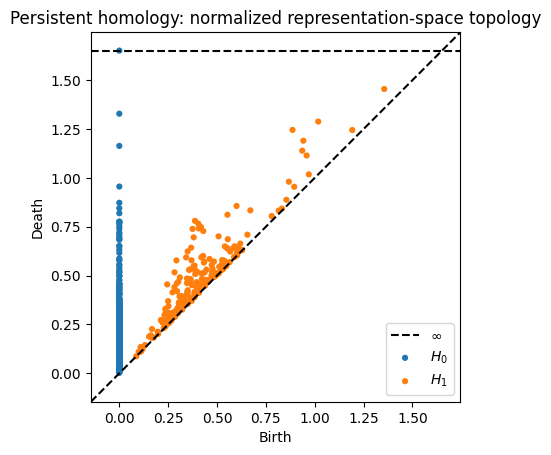

In [14]:
if HAS_TDA and len(cosmic_df) > 30:

    sample = cosmic_df.sample(
        min(700, len(cosmic_df)),
        random_state=SEED
    )

    X_tda = (
        sample[GEOMETRY_COLS]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .values
    )

    # GEOMETRY_COLS are already dataset-aware normalized.
    # This second scaling only stabilizes numerical ranges for ripser.
    X_tda = StandardScaler().fit_transform(X_tda)

    diagrams = ripser(X_tda, maxdim=1)["dgms"]

    plot_diagrams(diagrams, show=False)
    plt.title("Persistent homology: normalized representation-space topology")
    plt.show()

else:
    print("TDA skipped.")

### Interpretation — Persistent Homology in Normalized Representation Space

Persistent homology is used here to study the stability of organizational structures across multiple neighborhood scales within the normalized representation space.

Rather than focusing on individual observations, this analysis examines how collective structural relationships emerge and persist as local neighborhoods expand.

Interpretation of topological features:

- `H₀` components correspond to connected organizational regions or clustered structures within the representation space.
- `H₁` structures correspond to loop-like or void-like organizational patterns that persist across multiple spatial scales.

Observed behavior:

- The persistence diagram exhibits a dominant `H₀` regime, indicating that much of the normalized representation space organizes into coherent connected structures.
- A smaller but nontrivial population of persistent `H₁` features is also visible, suggesting the presence of mesoscale organizational loops or filament-like structures within the latent geometry.
- Most topological features decay relatively close to the diagonal, indicating moderate persistence rather than extremely rigid large-scale topology.

Interpretational significance:

- The emergence of persistent organizational structure suggests that the integrated multisource representation space is not behaving as purely random high-dimensional noise.
- The topology appears compatible with structured latent organization across heterogeneous observational and simulation-derived datasets.
- Persistent homology therefore functions here as a topology-aware organizational descriptor for representation-space analysis.

Important limitations:

- These topological structures emerge from normalized representation-space geometry rather than direct physical spacetime topology.
- The observed persistence structure may partly reflect feature engineering, normalization choices, sampling density, or manifold geometry effects.
- No claim is made regarding dark matter physics, hidden cosmological topology, simulation hypotheses, or new astrophysical mechanisms.

Governance note:

Persistent homology is used here as an exploratory organizational metric within a governed representation-learning framework. The resulting structures should therefore be interpreted as latent geometric patterns within heterogeneous astronomical data representations rather than evidence of hidden physical laws.

# Module 3 — Representation Learning and Latent Structure Discovery

After constructing normalized geometric and information-theoretic descriptors, the next stage explores whether heterogeneous cosmological datasets organize into coherent latent structures within representation space.

This module applies unsupervised representation-learning methods to the combined COSMIC-LATENT feature matrix in order to:

- identify recurring structural organization,
- compare observational and simulated datasets,
- detect regions of manifold overlap and separation,
- and investigate computationally unusual objects under uncertainty.

The objective is not to create a physically unified cosmological coordinate system.

Instead, the goal is to study how observational catalogues, morphology descriptors, density statistics, and simulation-derived quantities organize within a shared computational representation framework.

The methods used in this module include:

- robust feature normalization,
- manifold learning (UMAP),
- principal-component compression,
- autoencoder latent bottlenecks,
- and reconstruction-based anomaly estimation.

Interpretive constraints:

- Latent manifolds are representation-space constructions rather than physical maps of spacetime.
- Local neighborhood preservation does not imply cosmological causality.
- Apparent structures may emerge from survey conventions, feature engineering choices, or dataset-specific biases.

Governance note: Representation learning is treated here as an exploratory organizational tool intended to support comparative analysis under uncertainty rather than direct cosmological inference.

In [15]:
def build_feature_matrix(df):
    cols = [
        # Normalized representation geometry
        "x_norm", "y_norm", "z_norm",

        # Information geometry
        "local_density", "local_entropy", "density_gradient",

        # SDSS colours
        "u_g", "g_r", "r_i", "i_z",

        # Euclid morphology / quality
        "flux_vis_psf", "flux_detection_total", "flux_vis_sersic",
        "blended_prob", "point_like_prob", "extended_prob", "spurious_prob",
        "segmentation_area", "semimajor_axis", "position_angle",
        "ellipticity", "kron_radius", "fwhm",

        # IllustrisTNG simulation features
        "mass", "mass_stars", "mass_dm", "sfr", "halfmassrad",
        "dark_to_stellar_mass_ratio", "log_mass"
    ]

    cols = [c for c in cols if c in df.columns]

    Xraw = (
        df[cols]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
    )

    valid = [
        c for c in Xraw.columns
        if Xraw[c].notna().sum() >= max(20, int(0.10 * len(Xraw)))
    ]

    Xraw = Xraw[valid].fillna(Xraw[valid].median(numeric_only=True))

    scaler = RobustScaler()

    Xscaled = scaler.fit_transform(Xraw)

    # Final clipping to prevent catastrophic latent explosions
    Xscaled = np.clip(Xscaled, -10, 10)

    return Xscaled, valid


X, feature_cols = build_feature_matrix(cosmic_df) if len(cosmic_df) else (None, [])

print("Feature matrix:", None if X is None else X.shape)
print(feature_cols)


Feature matrix: (4250, 20)
['x_norm', 'y_norm', 'z_norm', 'local_density', 'local_entropy', 'density_gradient', 'u_g', 'g_r', 'r_i', 'i_z', 'flux_vis_psf', 'flux_detection_total', 'flux_vis_sersic', 'point_like_prob', 'spurious_prob', 'segmentation_area', 'semimajor_axis', 'position_angle', 'ellipticity', 'fwhm']


In [16]:
if X is not None and len(cosmic_df) > 5:

    pca = PCA(n_components=2, random_state=SEED)
    pca_emb = pca.fit_transform(X)
    cosmic_df["pca_1"], cosmic_df["pca_2"] = pca_emb[:, 0], pca_emb[:, 1]

    if HAS_UMAP and len(cosmic_df) > 20:
        emb = umap.UMAP(
            n_components=2,
            n_neighbors=25,
            min_dist=0.08,
            random_state=SEED
        ).fit_transform(X)

        cosmic_df["umap_1"], cosmic_df["umap_2"] = emb[:, 0], emb[:, 1]

    else:
        cosmic_df["umap_1"], cosmic_df["umap_2"] = cosmic_df["pca_1"], cosmic_df["pca_2"]

    try:
        sp = SpectralEmbedding(
            n_components=2,
            n_neighbors=min(20, len(cosmic_df) - 1),
            random_state=SEED
        ).fit_transform(X)

        cosmic_df["spectral_1"], cosmic_df["spectral_2"] = sp[:, 0], sp[:, 1]

    except Exception as e:
        print("Spectral skipped:", repr(e))

    plot_df = cosmic_df.copy()
    plot_df["density_plot_size"] = pd.to_numeric(
        plot_df["local_density"],
        errors="coerce"
    )

    # Prevent extremely dense points from visually dominating the map.
    plot_df["density_plot_size"] = plot_df["density_plot_size"].clip(
        upper=plot_df["density_plot_size"].quantile(0.95)
    )

    fig_umap_manifold = px.scatter(
        plot_df,
        x="umap_1",
        y="umap_2",
        color="dataset_name",
        size="density_plot_size",
        hover_data=[
            "dataset_name",
            "source_label",
            "data_channel",
            "local_entropy",
            "density_gradient"
        ],
        title="Latent manifold across sources in normalized representation space",
        opacity=0.75
    )

    fig_umap_manifold.update_layout(height=680)
    fig_umap_manifold.show()


### Interpretation — Latent Manifold Across Heterogeneous Cosmological Sources

This UMAP projection shows how SDSS, Euclid, and IllustrisTNG objects organize when normalized geometric descriptors, information-theoretic quantities, photometric features, morphology indicators, and simulation-derived measurements are embedded into a shared latent representation space.

The embedding is designed to preserve local neighborhood structure while compressing the high-dimensional feature space into a lower-dimensional comparative manifold.

Key observations:

- SDSS forms a dense and comparatively continuous observational manifold rather than random scatter, suggesting internally coherent photometric and structural organization.
- Euclid separates into multiple branch-like and island-like structures, consistent with the influence of morphology-sensitive segmentation and detection-quality variables.
- IllustrisTNG partially overlaps with the SDSS manifold while retaining distinct local structure, suggesting both convergence and divergence between simulated and observational cosmological representations.
- Several manifold regions exhibit smooth internal continuity rather than fragmented numerical noise, indicating that the learned representation preserves meaningful neighborhood organization.

Interpretational significance:

- The separation between datasets should not be interpreted as evidence that one dataset is "correct" and another is "incorrect." Instead, it reflects differences in observational strategy, morphology encoding, simulation assumptions, and feature composition.
- Partial overlap between SDSS and IllustrisTNG is computationally interesting because it suggests that some structural relationships captured in the simulation are also present in real observational data.
- Euclid’s branching geometry suggests that morphology-oriented variables strongly shape the latent organizational topology of the catalogue.

Important limitations:

- This manifold is not a physical map of spacetime or cosmological structure.
- UMAP preserves local neighborhood relationships more reliably than large-scale global distances, meaning cluster separation should be interpreted cautiously.
- Apparent structures may partly reflect preprocessing choices, normalization procedures, feature engineering, or dataset-specific biases.

Governance note:

This latent manifold is intended as a representation-space diagnostic for comparative exploratory analysis across heterogeneous cosmological datasets. The embedding should therefore be interpreted as an organizational visualization tool rather than evidence for hidden astrophysical mechanisms or new cosmological laws.

In [17]:
if X is not None:

    if HAS_TF and len(cosmic_df) > 100:
        tf.random.set_seed(SEED)

        input_dim = X.shape[1]

        model = keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(64, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(2, activation="linear", name="bottleneck"),
            layers.Dense(16, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(input_dim, activation="linear"),
        ])

        model.compile(
            optimizer="adam",
            loss="mse"
        )

        history = model.fit(
            X,
            X,
            epochs=40,
            batch_size=64,
            verbose=0,
            validation_split=0.15
        )

        Xhat = model.predict(X, verbose=0)

        cosmic_df["ae_reconstruction_error"] = np.mean(
            (X - Xhat) ** 2,
            axis=1
        )

        # Optional: extract the 2D autoencoder bottleneck as another latent view.
        encoder = keras.Model(
            inputs=model.layers[0].input,
            outputs=model.get_layer("bottleneck").output
        )

        bottleneck = encoder.predict(X, verbose=0)
        cosmic_df["ae_latent_1"] = bottleneck[:, 0]
        cosmic_df["ae_latent_2"] = bottleneck[:, 1]

    else:
        pca3 = PCA(
            n_components=min(3, X.shape[1]),
            random_state=SEED
        )

        low = pca3.fit_transform(X)
        Xhat = pca3.inverse_transform(low)

        cosmic_df["ae_reconstruction_error"] = np.mean(
            (X - Xhat) ** 2,
            axis=1
        )

        cosmic_df["ae_latent_1"] = low[:, 0]
        cosmic_df["ae_latent_2"] = low[:, 1] if low.shape[1] > 1 else 0


In [18]:
fig_autoencoder = px.scatter(
    cosmic_df,
    x="ae_latent_1",
    y="ae_latent_2",
    color=np.log1p(cosmic_df['ae_reconstruction_error']),
    symbol="dataset_name",
    title='Autoencoder latent manifold colored by log reconstruction anomaly',
    opacity=0.75,
    hover_data=[
        "dataset_name",
        "source_label",
        "local_entropy",
        "density_gradient"
    ]
)

fig_autoencoder.update_layout(height=700)
fig_autoencoder.show()

### Interpretation — Autoencoder Latent Manifold and Reconstruction Anomaly

The autoencoder compresses the multisource cosmological feature matrix into a two-dimensional latent bottleneck and then attempts to reconstruct the original high-dimensional representation.

Objects that reconstruct poorly receive higher reconstruction anomaly scores because the model struggles to represent them using the dominant learned organizational patterns.

Key observations:

- Most objects occupy dense low-anomaly regions, suggesting that the autoencoder successfully learned recurring structural organization within the combined representation space.
- Several sparse branches, transitional regions, and manifold edges exhibit elevated reconstruction error, indicating objects that are more difficult for the model to compress and reconstruct consistently.
- High-error regions appear concentrated near low-density organizational zones and manifold discontinuities rather than uniformly distributed across the latent space.
- The latent geometry itself exhibits smooth trajectories and branching behavior, suggesting that the learned bottleneck preserves meaningful organizational continuity rather than random compression noise.

Interpretational significance:

- Reconstruction error functions here as an exploratory representation-space anomaly signal.
- High anomaly values do not necessarily indicate physically exotic astronomical objects.
- Instead, they indicate objects whose feature combinations differ from the dominant statistical and structural regularities learned by the model.
- Such regions may correspond to:
  - rare morphologies,
  - unusual local density environments,
  - simulation-observation divergences,
  - lower-confidence detections,
  - or underrepresented feature configurations.

Important limitations:

- Autoencoder anomalies are highly model-dependent and sensitive to architecture, scaling choices, and feature composition.
- Elevated reconstruction error can arise from missing values, survey imbalance, preprocessing artifacts, or heterogeneous feature coverage across datasets.
- The latent bottleneck is a computational representation space rather than a physical cosmological embedding.
- The autoencoder does not identify "dark matter objects" or hidden astrophysical entities directly.

Governance note:

Autoencoder anomaly scores are treated here as exploratory inference triggers rather than scientific conclusions. High-scoring regions should therefore be routed into the governance framework for evidence scoring, uncertainty assessment, and cautious interpretive handling before any substantive scientific interpretation is attempted.

# Module 4 — Anomaly Detection, Graph Structure, and Governed Exploration

After constructing latent manifolds and representation-space embeddings, the next stage investigates whether unusual organizational regions can be identified systematically within the multisource cosmological representation framework.

This module combines:

- isolation-based anomaly detection,
- local graph neighborhood analysis,
- reconstruction anomaly estimation,
- and composite anomaly aggregation

in order to identify observations that differ from dominant learned structural patterns.

The objective is not to declare the discovery of exotic astrophysical phenomena.

Instead, the goal is to study how computationally unusual structures emerge within heterogeneous observational and simulation-derived representation spaces under controlled interpretive constraints.

The anomaly framework integrates multiple complementary perspectives:

- statistical isolation within feature space,
- deviation from local neighborhood organization,
- reconstruction instability within latent compression models,
- and graph-topological contextualization.

This produces a composite anomaly index intended to support exploratory ranking rather than categorical classification.

Interpretive constraints:

- Anomaly scores indicate unusual representation-space organization rather than direct physical abnormality.
- High-scoring objects may arise from survey artifacts, sparse sampling regions, preprocessing effects, morphology rarity, or simulation-observation divergence.
- Graph and manifold structure should be interpreted as organizational diagnostics rather than evidence of hidden cosmological mechanisms.

Governance note:

All anomaly outputs in this module remain subject to the notebook’s governance framework. Computational anomaly is therefore treated as an inference trigger requiring evidence scoring, uncertainty assessment, and interpretive restraint before any scientific interpretation is considered.

In [19]:
if X is not None and len(cosmic_df) > 30:

    iso = IsolationForest(
        n_estimators=300,
        contamination=0.06,
        random_state=SEED
    )

    cosmic_df["iso_anomaly_score"] = -iso.fit(X).score_samples(X)
    cosmic_df["iso_anomaly_flag"] = (iso.predict(X) == -1).astype(int)

    if (
        knn_indices is not None
        and "local_entropy" in cosmic_df.columns
        and "local_density" in cosmic_df.columns
    ):
        ent = cosmic_df["local_entropy"].values
        dens = cosmic_df["local_density"].values

        em = np.array([ent[n[1:]].mean() for n in knn_indices])
        dm = np.array([dens[n[1:]].mean() for n in knn_indices])

        cosmic_df["graph_anomaly_score"] = (
            np.abs(ent - em) / (np.nanstd(ent) + 1e-9)
            + np.abs(dens - dm) / (np.nanstd(dens) + 1e-9)
        )
    else:
        cosmic_df["graph_anomaly_score"] = cosmic_df["iso_anomaly_score"]

    anomaly_components = [
        "iso_anomaly_score",
        "graph_anomaly_score",
        "ae_reconstruction_error"
    ]

    for col in anomaly_components:
        if col in cosmic_df.columns:
            vals = pd.to_numeric(cosmic_df[col], errors="coerce")
            vals = vals.fillna(vals.median())
            cosmic_df[col + "_norm"] = MinMaxScaler().fit_transform(vals.to_frame())

    cosmic_df["cosmic_anomaly_index"] = (
        0.40 * cosmic_df["iso_anomaly_score_norm"]
        + 0.30 * cosmic_df["graph_anomaly_score_norm"]
        + 0.30 * cosmic_df["ae_reconstruction_error_norm"]
    )

    cosmic_df["cosmic_anomaly_flag"] = (
        cosmic_df["cosmic_anomaly_index"]
        >= cosmic_df["cosmic_anomaly_index"].quantile(0.94)
    ).astype(int)

    display_cols = [
        "dataset_name", "source_label",
        "x_norm", "y_norm", "z_norm",
        "local_density", "local_entropy",
        "iso_anomaly_score",
        "graph_anomaly_score",
        "ae_reconstruction_error",
        "cosmic_anomaly_index"
    ]

    display(
        cosmic_df
        .sort_values("cosmic_anomaly_index", ascending=False)
        .head(15)[[c for c in display_cols if c in cosmic_df.columns]]
    )

    fig_anomaly_map = px.scatter(
        cosmic_df,
        x="umap_1",
        y="umap_2",
        color="cosmic_anomaly_index",
        symbol="dataset_name",
        title="Latent manifold colored by composite anomaly index",
        opacity=0.8,
        hover_data=[
            "dataset_name",
            "source_label",
            "local_density",
            "local_entropy",
            "iso_anomaly_score",
            "graph_anomaly_score",
            "ae_reconstruction_error"
        ]
    )

    fig_anomaly_map.update_layout(height=700)
    fig_anomaly_map.show()


,dataset_name,source_label,x_norm,y_norm,z_norm,local_density,local_entropy,iso_anomaly_score,graph_anomaly_score,ae_reconstruction_error,cosmic_anomaly_index
2350,Euclid,Euclid_Q1_COSMOS_MER,0.298411,0.683506,-1.074231,3.610319,3.822399,0.568260,0.136193,6.619893,0.585394
3041,Euclid,Euclid_Q1_COSMOS_MER,-0.188348,-1.516282,0.258541,3.123429,3.818733,0.619196,1.039587,3.903310,0.566341
3487,Euclid,Euclid_Q1_COSMOS_MER,1.181740,1.181918,0.817248,3.910167,3.766516,0.580006,0.112964,5.496632,0.547108
3698,Euclid,Euclid_Q1_COSMOS_MER,-1.797890,-0.554616,1.101243,3.229777,3.850249,0.644655,1.053145,2.518863,0.534103
3982,Euclid,Euclid_Q1_COSMOS_MER,1.920535,-0.718189,1.413782,1.989459,3.800556,0.671422,0.351494,2.487970,0.529635
3613,Euclid,Euclid_Q1_COSMOS_MER,1.126384,1.337226,0.991832,3.584418,3.685897,0.652194,1.501673,1.548595,0.520985
2970,Euclid,Euclid_Q1_COSMOS_MER,0.041141,1.319365,0.153750,3.879561,3.726717,0.591764,0.853470,3.762921,0.518667
3468,Euclid,Euclid_Q1_COSMOS_MER,-0.842281,1.402648,0.795169,3.523735,3.754392,0.641119,0.995363,2.318363,0.518029
3545,Euclid,Euclid_Q1_COSMOS_MER,0.406461,-1.793141,0.907714,3.544467,3.848182,0.648840,0.322522,2.803221,0.516021
3030,Euclid,Euclid_Q1_COSMOS_MER,-0.186142,-1.511340,0.247627,3.190934,3.818630,0.651694,0.967563,2.020749,0.515573


### Interpretation — Composite Anomaly Map in Latent Representation Space

This figure projects the multisource COSMIC-LATENT representation space into a two-dimensional UMAP manifold and colors each object according to its composite anomaly index.

The anomaly index combines three complementary signals:

- **Isolation Forest anomaly**: statistical rarity within the feature space.
- **Graph anomaly**: disagreement with local neighborhood organization.
- **Autoencoder reconstruction anomaly**: difficulty compressing and reconstructing the object within the learned latent representation.

The resulting score therefore represents a composite measure of representation-space unusualness rather than a single-model anomaly estimate.

Key observations:

- Elevated anomaly scores tend to cluster near manifold edges, sparse branches, and transitional organizational zones rather than appearing uniformly across the latent space.
- Dense interior regions generally exhibit lower anomaly values, suggesting that the anomaly framework is responding to deviations from stable learned organizational structure.
- Several Euclid submanifolds contain localized high-anomaly pockets, potentially reflecting morphology-sensitive segmentation behavior, detection-quality effects, or underrepresented structural configurations.
- SDSS exhibits a more continuous observational manifold, with anomaly gradients distributed primarily along low-density boundaries and manifold transition regions.
- The anomaly landscape appears spatially structured rather than randomly dispersed, suggesting that the combined anomaly framework is interacting coherently with the learned representation geometry.

Interpretational significance:

- The anomaly framework identifies observations that are computationally unusual relative to the dominant learned organization of the integrated representation space.
- High-scoring objects are therefore best interpreted as candidates for closer inspection rather than direct evidence of physically exotic phenomena.
- In this notebook, anomaly means “representation-space deviation” rather than “cosmological abnormality.”

Important limitations:

- The anomaly index depends strongly on feature selection, normalization strategy, latent geometry construction, and model hyperparameters.
- Apparent anomalies may emerge from:
  - survey-specific measurement conventions,
  - missing-value structure,
  - heterogeneous feature coverage,
  - morphology rarity,
  - preprocessing artifacts,
  - or simulation-observation divergence.
- UMAP geometry itself is nonlinear and locally optimized, meaning large-scale distances and cluster separation should be interpreted cautiously.

Governance note:

Composite anomaly scores are treated here as exploratory triage signals operating under uncertainty. High-scoring regions should therefore trigger additional evidence review, uncertainty assessment, and interpretive restraint rather than standalone scientific conclusions.

In [20]:
if len(cosmic_df) > 30 and knn_indices is not None and "cosmic_anomaly_index" in cosmic_df.columns:

    sample_idx = cosmic_df.sample(
        min(300, len(cosmic_df)),
        random_state=SEED
    ).index.to_numpy()

    sample_set = set(sample_idx)

    G = nx.Graph()

    for idx in sample_idx:
        G.add_node(
            idx,
            dataset=cosmic_df.loc[idx, "dataset_name"],
            anomaly=float(cosmic_df.loc[idx, "cosmic_anomaly_index"])
        )

        for n in knn_indices[idx][1:5]:
            if n in sample_set:
                G.add_edge(idx, n)

    pos = nx.spring_layout(G, seed=SEED, k=0.2)

    edge_x = []
    edge_y = []

    for e0, e1 in G.edges():
        x0, y0 = pos[e0]
        x1, y1 = pos[e1]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    fig_graph_neighbourhoods = go.Figure()

    fig_graph_neighbourhoods.add_trace(
        go.Scatter(
            x=edge_x,
            y=edge_y,
            mode="lines",
            line=dict(width=0.5),
            hoverinfo="none"
        )
    )

    fig_graph_neighbourhoods.add_trace(
        go.Scatter(
            x=[pos[n][0] for n in G.nodes()],
            y=[pos[n][1] for n in G.nodes()],
            mode="markers",
            marker=dict(
                size=7,
                color=[G.nodes[n]["anomaly"] for n in G.nodes()],
                showscale=True,
                colorbar=dict(title="Anomaly")
            ),
            text=[
                f"{G.nodes[n]['dataset']}<br>Anomaly: {G.nodes[n]['anomaly']:.3f}"
                for n in G.nodes()
            ],
            hoverinfo="text"
        )
    )

    fig_graph_neighbourhoods.update_layout(
        title="Graph structure of local cosmological neighbourhoods colored by anomaly",
        height=650,
        showlegend=False
    )

    fig_graph_neighbourhoods.show()

### Interpretation — Graph Structure of Local Cosmological Neighborhoods

This graph represents local neighborhood relationships between sampled objects within the COSMIC-LATENT representation space.

Each node corresponds to an object, while edges connect nearby objects according to the K-nearest-neighbor structure constructed during the information-geometry stage.

Node color represents the composite anomaly index.

Key observations:

- Anomaly scores are not uniformly distributed throughout the graph.
- Higher-anomaly nodes tend to appear within sparse connection zones, transitional bridge regions, or locally unusual neighborhoods rather than dense highly connected regions.
- Several anomalous nodes appear embedded within coherent local substructures instead of existing as completely isolated outliers.
- The graph therefore suggests that anomaly can emerge relationally through neighborhood organization rather than purely through extreme individual feature values.

Interpretational significance:

- The graph perspective provides contextual information that is not visible in purely point-based anomaly scoring.
- Some objects may appear anomalous because they occupy structurally unstable or weakly connected regions of the representation topology.
- Neighborhood-aware anomaly structure may reflect:
  - rare morphology regimes,
  - unusual local density environments,
  - survey segmentation behavior,
  - simulation-observation divergence,
  - or heterogeneous feature composition across datasets.
- This supports the broader hypothesis that exploratory anomaly analysis benefits from topology-aware contextualization rather than isolated scalar scoring alone.

Important limitations:

- The circular arrangement is produced by a force-directed graph layout and does not represent physical cosmological geometry.
- Graph edges encode similarity relationships within normalized representation space rather than gravitational or astrophysical interactions.
- The visualization uses a sampled subset of the full graph for readability and should therefore be interpreted as a diagnostic organizational view rather than a complete network reconstruction.
- Apparent graph structures may partly depend on neighborhood hyperparameters and manifold sampling density.

Governance note:

This graph functions as a relational anomaly triage tool within the governed exploratory framework. It is intended to help identify regions deserving closer inspection while preserving interpretive caution regarding the relationship between representation-space topology and physical cosmological structure.

# Module 5 — Epistemic Governance and Interpretive Constraints

Modern AI systems are highly effective at detecting unusual statistical, geometric, and topological patterns within high-dimensional data.

However, anomaly detection alone does not justify scientific interpretation.

This notebook therefore introduces a lightweight epistemic governance layer intended to distinguish between:

- direct observation,
- representation-space organization,
- structural inference,
- speculative interpretation,
- and unsupported conclusions.

The objective is not to suppress exploratory analysis.

Instead, the goal is to preserve interpretive discipline when working with heterogeneous cosmological datasets, latent manifolds, topology-aware anomaly systems, and representation-learning architectures operating under uncertainty.

Within the COSMIC-LATENT framework, governance functions as a constraint layer that helps regulate how computational outputs are interpreted, communicated, and escalated.

This includes:

- evidence scoring,
- interpretive risk estimation,
- anomaly contextualization,
- and epistemic tagging.

Interpretive categories such as:

- `observed`,
- `inferred`,
- `speculative`,
- and `unsupported`

are therefore treated as governance states rather than scientific verdicts.

Importantly, this notebook is intentionally separated from the accompanying speculative exploratory notebook.

Notebook 1 focuses on:
- governed methodology,
- representation-space analysis,
- uncertainty-aware interpretation,
- and computational epistemology.

More speculative cosmological interpretations, exploratory hypotheses, and frontier visual analyses are intentionally isolated within Notebook 2 in order to preserve methodological clarity and interpretive separation.

Governance note:

The purpose of this module is not to eliminate scientific imagination, but to ensure that exploratory AI systems operating in uncertain scientific environments maintain transparent boundaries between computation, inference, speculation, and claim-making.


In [21]:

def add_governance_layer(df):
    """Add epistemic tags based on evidence quality and anomaly risk.

    Design choices:
    - Missing Euclid-specific quality fields do NOT penalize SDSS or TNG.
    - Galaxy Zoo votes can slightly increase support for SDSS objects when matched.
    - IllustrisTNG is valid scientific evidence, but it is model-world evidence, not direct observation.
    """
    if df is None or len(df) == 0:
        return df

    out = df.copy()
    out["evidence_score"] = 0.70

    # Euclid catalogue quality / uncertainty signals.
    # Missing values are neutral, not suspicious.
    if "spurious_prob" in out.columns:
        out["evidence_score"] -= (
            0.35
            * pd.to_numeric(out["spurious_prob"], errors="coerce")
            .fillna(0)
            .clip(0, 1)
        )

    if "extended_prob" in out.columns:
        out["evidence_score"] += (
            0.10
            * pd.to_numeric(out["extended_prob"], errors="coerce")
            .fillna(0)
            .clip(0, 1)
        )

    if "blended_prob" in out.columns:
        out["evidence_score"] -= (
            0.15
            * pd.to_numeric(out["blended_prob"], errors="coerce")
            .fillna(0)
            .clip(0, 1)
        )

    if "det_quality_flag" in out.columns:
        out["evidence_score"] -= (
            0.05
            * (
                pd.to_numeric(out["det_quality_flag"], errors="coerce")
                .fillna(0) != 0
            ).astype(float)
        )

    # Galaxy Zoo human-consensus support, if available after the clean merge.
    if "total_votes" in out.columns:
        votes = pd.to_numeric(out["total_votes"], errors="coerce").fillna(0)
        max_votes = np.log1p(votes).max()
        vote_support = np.log1p(votes) / (max_votes + 1e-9) if max_votes > 0 else 0
        out["evidence_score"] += 0.10 * vote_support

    if "gz_artifact_prob" in out.columns:
        out["evidence_score"] -= (
            0.20
            * pd.to_numeric(out["gz_artifact_prob"], errors="coerce")
            .fillna(0)
            .clip(0, 1)
        )

    # Simulations are model-world evidence, so keep them valid but slightly distinct.
    if "data_channel" in out.columns:
        is_sim = out["data_channel"].astype(str).str.contains("simulation", case=False, na=False)
        out.loc[is_sim, "evidence_score"] -= 0.05

    out["evidence_score"] = out["evidence_score"].clip(0, 1)

    # Interpretive risk comes from composite anomaly strength.
    if "cosmic_anomaly_index" in out.columns:
        vals = pd.to_numeric(out["cosmic_anomaly_index"], errors="coerce").fillna(0)
        out["interpretive_risk"] = MinMaxScaler().fit_transform(vals.to_frame())
    else:
        out["interpretive_risk"] = 0.0

    def tag(row):
        if row["evidence_score"] < 0.25:
            return "unsupported"
        if row["interpretive_risk"] > 0.85 and row["evidence_score"] < 0.55:
            return "speculative"
        if row["interpretive_risk"] > 0.70:
            return "inferred"
        return "observed"

    out["epistemic_tag"] = out.apply(tag, axis=1)
    return out


cosmic_df = add_governance_layer(cosmic_df)

if len(cosmic_df):
    display(
        cosmic_df[
            [
                "dataset_name",
                "cosmic_anomaly_index",
                "evidence_score",
                "interpretive_risk",
                "epistemic_tag",
            ]
        ].head(20)
    )

    summary = (
        cosmic_df
        .groupby(["dataset_name", "epistemic_tag"])
        .size()
        .reset_index(name="count")
    )

    fig = px.bar(
        summary,
        x="dataset_name",
        y="count",
        color="epistemic_tag",
        barmode="group",
        title="Governance tags by dataset"
    )

    fig.show()
    display(summary)


,dataset_name,cosmic_anomaly_index,evidence_score,interpretive_risk,epistemic_tag
0,SDSS,0.123052,0.7,0.196955,observed
1,SDSS,0.145922,0.7,0.236677,observed
2,SDSS,0.220329,0.7,0.365916,observed
3,SDSS,0.199660,0.7,0.330015,observed
4,SDSS,0.077434,0.7,0.117721,observed
5,SDSS,0.033356,0.7,0.041162,observed
6,SDSS,0.059879,0.7,0.087230,observed
7,SDSS,0.049659,0.7,0.069478,observed
8,SDSS,0.049006,0.7,0.068343,observed
9,SDSS,0.044933,0.7,0.061269,observed


,dataset_name,epistemic_tag,count
0,Euclid,inferred,65
1,Euclid,observed,1930
2,Euclid,speculative,5
3,IllustrisTNG,observed,250
4,SDSS,observed,2000


Interpretation — Governance tags by dataset

This figure summarizes how the COSMIC-LATENT governance layer classifies objects across the multisource representation space.

The governance system combines:

- anomaly intensity,
- local relational context,
- reconstruction uncertainty,
- and observational evidence quality

to assign lightweight epistemic tags.

The categories are:

- `observed` → objects remaining within relatively stable and well-supported representation regimes,
- `inferred` → objects showing elevated anomaly or structural uncertainty requiring cautious interpretation,
- `speculative` → highly uncertain regions where computational signals become weak or unstable.

Key observations:

- Most objects across SDSS, Euclid, and IllustrisTNG remain in the `observed` category.
- Euclid contains a noticeably larger inferred population compared to SDSS and IllustrisTNG.
- A very small number of Euclid objects enter the speculative regime.

Interpretational significance:

- The dominance of the observed category suggests that the anomaly system is not indiscriminately labeling large portions of the dataset as unusual.
- The larger inferred population in Euclid is likely related to its morphology-rich observational structure, segmentation complexity, and heterogeneous detection characteristics.
- The speculative category remains intentionally rare, reflecting the conservative design of the governance framework.

Important limitations:

- These governance labels are computational interpretive states, not astrophysical classifications.
- `Inferred` does not mean “new physics.”
- `Speculative` does not imply discovery or exotic cosmological phenomena.
- The governance layer depends on the chosen thresholds, normalization procedures, and feature availability across datasets.

Governance note:

This module represents the central methodological safeguard of Notebook 1.

Its purpose is to maintain separation between:
- observational evidence,
- representation-space anomaly,
- exploratory inference,
- and speculative interpretation.

This separation becomes especially important within the broader two-notebook COSMIC-LATENT architecture, where more speculative exploratory analyses are intentionally isolated into Notebook 2.

In [22]:

gz_like = [
    c for c in cosmic_df.columns
    if c.startswith("gz_")
    or c in ["galaxy_zoo_class", "total_classifications", "total_votes"]
] if len(cosmic_df) else []

print("Galaxy Zoo morphology/governance columns:", gz_like[:30])

if gz_like and "cosmic_anomaly_index" in cosmic_df.columns:
    display_cols = [
        "dataset_name",
        "cosmic_anomaly_index",
        "epistemic_tag",
        "evidence_score",
    ] + gz_like[:12]

    gz_view = (
        cosmic_df[display_cols]
        .dropna(how="all", subset=gz_like[:12])
        .head(20)
    )

    if len(gz_view):
        display(gz_view)
    else:
        print("Galaxy Zoo columns are present, but no rows matched the current SDSS sample.")
else:
    print("No Galaxy Zoo morphology columns available in cosmic_df.")


Galaxy Zoo morphology/governance columns: ['galaxy_zoo_class', 'gz_smooth_prob', 'gz_disk_features_prob', 'gz_artifact_prob', 'gz_edgeon_prob', 'gz_bar_prob', 'gz_spiral_prob', 'gz_no_bulge_prob', 'gz_dominant_bulge_prob', 'total_classifications', 'total_votes']
Galaxy Zoo columns are present, but no rows matched the current SDSS sample.


Interpretation — Galaxy Zoo morphology integration

The COSMIC-LATENT framework includes an optional integration layer for Galaxy Zoo morphology annotations.

Galaxy Zoo is a large citizen-science project in which human volunteers visually classify galaxies according to structural appearance, including:

- smooth elliptical structure,
- disk features,
- spiral morphology,
- bars,
- edge-on orientation,
- and possible imaging artifacts.

The governance-oriented morphology table successfully loaded and exposed multiple morphology-confidence variables.

Key observations:

- The Galaxy Zoo catalogue was successfully downloaded and processed.
- Morphology governance variables were correctly identified and integrated into the pipeline architecture.
- However, no direct matches were found between the current SDSS sample and the Galaxy Zoo subset during the merge stage.

Interpretational significance:

- The absence of matches does not indicate a pipeline failure.
- It most likely reflects differences between:
  - catalogue versions,
  - SDSS releases,
  - object identifiers,
  - sky coverage,
  - or sample-selection procedures.
- The pipeline nevertheless demonstrates the ability to incorporate external morphology-governance metadata into the broader representation-learning framework.

Methodological importance:

- This step illustrates how human-generated interpretive information can be integrated into AI-based anomaly systems.
- In future extensions, morphology-confidence variables could contribute directly to:
  - evidence scoring,
  - interpretive uncertainty estimation,
  - and anomaly contextualization.

Important limitations:

- The current notebook should not claim successful morphology matching for the analyzed SDSS subset.
- No downstream scientific interpretation should rely on Galaxy Zoo labels within the present run.
- Morphology-governance integration remains infrastructural and exploratory in this version of the notebook.

Governance note:

This result is scientifically valuable precisely because it documents a non-match transparently.

Recording failed joins, incomplete metadata overlap, and unresolved catalogue alignment issues is an important part of uncertainty-aware computational research.

## Multimodal Extension Layer — Future Image-Based Cosmological Features

The current COSMIC-LATENT notebook focuses primarily on tabular cosmological representations derived from:

- SDSS photometric catalogues,
- Euclid morphology and segmentation metadata,
- and IllustrisTNG simulation quantities.

However, many important cosmological structures are fundamentally image-based rather than tabular.

Examples include:

- strong gravitational lensing arcs,
- spiral morphology,
- tidal distortions,
- merger signatures,
- filamentary structures,
- and irregular observational artifacts.

To support future multimodal analysis, the notebook includes a lightweight image-feature extraction interface capable of generating:

- image entropy,
- brightness statistics,
- contrast structure,
- and morphology-aware descriptors

from FITS, PNG, or JPEG image cutouts.

Current status:

- The image-extension layer is infrastructural only in Notebook 1.
- No image-based cosmological claims are made in the present analysis.
- The extractor is included to demonstrate architectural extensibility and future compatibility with multimodal representation learning.

Interpretational significance:

This extension prepares the COSMIC-LATENT framework for future integration of:
- computer vision,
- multimodal latent spaces,
- morphology-aware anomaly detection,
- and image-conditioned governance systems.

Governance note:

Future image-based anomaly systems would require additional safeguards against:
- observational artifacts,
- compression artifacts,
- telescope-specific distortions,
- and interpretive overreach from visually compelling structures.

In [23]:
def extract_basic_image_features(image_array):
    img=np.asarray(image_array,dtype=float); img=img[np.isfinite(img)]
    if img.size==0: return {}
    img=img-np.nanmin(img); img=img/np.nanmax(img) if np.nanmax(img)>0 else img
    hist,_=np.histogram(img,bins=64,range=(0,1),density=True); p=hist/(hist.sum()+1e-12)
    return {'image_mean':float(np.mean(img)),'image_std':float(np.std(img)),'image_entropy':float(-np.sum(p*np.log2(p+1e-12))),'image_p99':float(np.percentile(img,99))}
print('Image feature extractor ready.')


Image feature extractor ready.


# Limitations and Interpretive Scope

This notebook presents an exploratory computational framework for studying heterogeneous cosmological representations using:

- representation learning,
- information geometry,
- topology-aware analysis,
- anomaly detection,
- and lightweight epistemic governance.

The methods presented here do not establish:

- physical causality,
- new cosmological laws,
- dark matter discovery,
- astrophysical ground truth,
- or statistically validated cosmological conclusions.

Instead, the notebook investigates how AI systems organize, separate, compress, and contextualize complex cosmological datasets within high-dimensional representation spaces.

Several important limitations remain:

- coordinate abstraction and normalization,
- heterogeneous survey biases,
- incomplete metadata alignment,
- simulation-observation mismatch,
- feature-selection sensitivity,
- limited statistical validation,
- dependence on representation-learning assumptions,
- and uncertainty introduced by dimensionality reduction techniques.

Additionally:

- latent manifolds are not physical spacetime maps,
- anomaly scores are model-relative rather than ontological,
- and topological structures emerge from representation geometry rather than direct cosmological topology.

The outputs should therefore be interpreted as exploratory computational structures operating under uncertainty rather than direct cosmological claims.

Governance note:

A central objective of the COSMIC-LATENT framework is to preserve explicit separation between:
- observation,
- representation,
- inference,
- speculation,
- and scientific claim-making.


# Relationship Between Notebook 1 and Notebook 2

The COSMIC-LATENT project is intentionally divided into two complementary notebooks.

## Notebook 1 — Methods and Governance

Notebook 1 focuses on:

- multisource cosmological data integration,
- normalized representation geometry,
- information-theoretic structure,
- topology-aware analysis,
- latent manifold learning,
- anomaly detection,
- uncertainty-aware interpretation,
- and epistemically constrained computational analysis.

The emphasis is methodological rigor, interpretive discipline, and exploratory computational epistemology.

## Notebook 2 — Speculative Exploratory Analysis

Notebook 2 is intentionally separated from the core methodological framework.

It explores:

- speculative interpretation,
- frontier visualizations,
- conceptual extrapolation,
- hypothesis generation,
- anomalous structural narratives,
- and exploratory cosmological imagination under uncertainty.

The purpose of Notebook 2 is not to replace scientific rigor, but to provide a sandbox for carefully isolated exploratory reasoning beyond the governance boundaries of Notebook 1.

## Why the separation matters

The separation between notebooks is itself part of the governance architecture.

It allows the project to:
- preserve methodological clarity,
- avoid conflating anomaly with discovery,
- maintain transparent interpretive boundaries,
- and still support exploratory scientific creativity.

This distinction is especially important when working with AI systems capable of generating compelling but potentially misleading high-dimensional structures and narratives.


# Interpretive Guardrails

The COSMIC-LATENT framework combines heterogeneous cosmological representations originating from fundamentally different observational and computational regimes.

Each source contributes a distinct informational perspective:

- **SDSS** contributes real spectroscopic galaxy observations and photometric structure.
- **Euclid** contributes high-resolution morphology, segmentation, and observational quality metadata.
- **IllustrisTNG** contributes simulated cosmological structure generated under a known physical model.
- **Galaxy Zoo** contributes human morphology annotations suitable for interpretive governance and morphology-aware comparison.
- **Strong lensing systems** are treated as future image-first anomaly environments requiring multimodal analysis rather than purely tabular interpretation.

These datasets should not be interpreted as interchangeable descriptions of the same cosmological space.

Instead, the notebook treats them as partially overlapping representational systems operating under different:
- observational assumptions,
- measurement processes,
- simulation constraints,
- and uncertainty structures.

The central contribution of the project is therefore not a claim about:
- dark matter particles,
- hidden cosmological intelligence,
- exotic physics,
- or new astrophysical laws.

Rather, the contribution is the design of a governed exploratory AI architecture capable of:
- integrating heterogeneous cosmological representations,
- organizing uncertainty-aware latent spaces,
- contextualizing anomaly under interpretive constraints,
- and preserving explicit separation between observation, inference, speculation, and claim-making.

# Conclusion

This notebook demonstrates a governed exploratory AI workflow for studying heterogeneous cosmological representation spaces under uncertainty.

By integrating:

- observational surveys,
- morphology catalogues,
- cosmological simulations,
- information geometry,
- manifold learning,
- topology-aware analysis,
- anomaly detection,
- and epistemic governance,

the COSMIC-LATENT framework illustrates how modern AI systems can be used to explore organizational structure while maintaining interpretive restraint.

The notebook is intentionally exploratory rather than confirmatory.

Its primary contribution is methodological and architectural rather than declarative.

More specifically, the project demonstrates:

- how heterogeneous cosmological datasets can be organized into shared representation spaces,
- how anomaly can be contextualized rather than sensationalized,
- how governance layers can regulate interpretation under uncertainty,
- and how exploratory computational epistemology may support future AI-assisted scientific workflows.

The framework does not claim discovery.

Instead, it proposes a structured way to navigate uncertainty when AI systems encounter complex and potentially misleading high-dimensional structure.

Within the broader two-notebook architecture:

- Notebook 1 focuses on governed methodology and constrained interpretation.
- Notebook 2 isolates speculative exploratory reasoning into a separate epistemic environment.

This separation is itself part of the governance design.

The broader goal is not to eliminate scientific imagination, but to develop AI-assisted exploratory systems that can support curiosity without collapsing the boundary between computational structure and scientific claim.


In [ ]:
# ============================================================
# COSMIC-LATENT — FINAL EXPORT CELL
# Exports processed tables, summary tables, named Plotly figures,
# open Matplotlib figures, metadata, and one ZIP archive.
# ============================================================

import os
import json
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

EXPORT_DIR = "/content/cosmic_latent_exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

print(f"Export directory: {EXPORT_DIR}")

# ============================================================
# 1. EXPORT CORE DATAFRAMES
# ============================================================

dataframes_to_export = {
    "cosmic_latent_processed_multisource": globals().get("cosmic_df"),
    "sdss_processed": globals().get("sdss_processed"),
    "euclid_processed": globals().get("euclid_processed"),
    "tng_processed": globals().get("tng_processed"),
    "galaxy_zoo_morphology": globals().get("gz_morphology"),
}

for name, df in dataframes_to_export.items():
    if isinstance(df, pd.DataFrame) and len(df) > 0:
        path = os.path.join(EXPORT_DIR, f"{name}.csv")
        df.to_csv(path, index=False)
        print(f"[CSV] Saved: {path}")

# ============================================================
# 2. EXPORT DERIVED ANALYSIS TABLES
# ============================================================

if "cosmic_df" in globals() and isinstance(cosmic_df, pd.DataFrame) and len(cosmic_df):

    if "cosmic_anomaly_index" in cosmic_df.columns:
        anomaly_path = os.path.join(
            EXPORT_DIR,
            "cosmic_latent_top_100_anomaly_candidates.csv"
        )

        cosmic_df.sort_values(
            "cosmic_anomaly_index",
            ascending=False
        ).head(100).to_csv(anomaly_path, index=False)

        print(f"[CSV] Saved: {anomaly_path}")

    if {"dataset_name", "epistemic_tag"}.issubset(cosmic_df.columns):
        governance_summary = (
            cosmic_df
            .groupby(["dataset_name", "epistemic_tag"])
            .size()
            .reset_index(name="count")
        )

        governance_path = os.path.join(
            EXPORT_DIR,
            "cosmic_latent_governance_summary.csv"
        )

        governance_summary.to_csv(governance_path, index=False)
        print(f"[CSV] Saved: {governance_path}")

# ============================================================
# 3. EXPORT NAMED PLOTLY FIGURES
# ============================================================
# To export all figures, make sure your plotting cells use names like:
# fig_entropy_cloud
# fig_feature_relation_map
# fig_latent_manifold
# fig_autoencoder_manifold
# fig_anomaly_map
# fig_graph_neighbourhoods
# fig_governance_tags

expected_plotly_figures = [
    "fig_entropy_cloud",
    "fig_feature_relation_map",
    "fig_latent_manifold",
    "fig_autoencoder_manifold",
    "fig_anomaly_map",
    "fig_graph_neighbourhoods",
    "fig_governance_tags",
]

plotly_figures = {}

for fig_name in expected_plotly_figures:
    fig_obj = globals().get(fig_name)
    if isinstance(fig_obj, go.Figure):
        plotly_figures[fig_name] = fig_obj

# Also catch any other explicitly named fig_* Plotly figures.
for var_name, obj in list(globals().items()):
    if (
        isinstance(obj, go.Figure)
        and var_name.startswith("fig_")
        and var_name not in plotly_figures
    ):
        plotly_figures[var_name] = obj

print(f"\nDetected Plotly figures: {list(plotly_figures.keys())}")

for fig_name, fig_obj in plotly_figures.items():

    html_path = os.path.join(EXPORT_DIR, f"{fig_name}.html")
    png_path = os.path.join(EXPORT_DIR, f"{fig_name}.png")

    try:
        fig_obj.write_html(html_path)
        print(f"[PLOTLY HTML] Saved: {html_path}")
    except Exception as e:
        print(f"[PLOTLY HTML] Failed for {fig_name}: {repr(e)}")

    try:
        fig_obj.write_image(png_path, scale=2)
        print(f"[PLOTLY PNG] Saved: {png_path}")
    except Exception as e:
        print(f"[PLOTLY PNG] Failed for {fig_name}: {repr(e)}")
        print("Tip: run `!pip install -U kaleido` once, then rerun this cell.")

# ============================================================
# 4. EXPORT CURRENT OPEN MATPLOTLIB FIGURES
# ============================================================

matplotlib_fig_nums = plt.get_fignums()

print(f"\nDetected open matplotlib figures: {matplotlib_fig_nums}")

for fig_num in matplotlib_fig_nums:
    try:
        fig_obj = plt.figure(fig_num)
        path = os.path.join(EXPORT_DIR, f"matplotlib_figure_{fig_num}.png")

        fig_obj.savefig(
            path,
            dpi=300,
            bbox_inches="tight"
        )

        print(f"[MATPLOTLIB] Saved: {path}")

    except Exception as e:
        print(f"[MATPLOTLIB] Failed for fig {fig_num}: {repr(e)}")

# ============================================================
# 5. EXPORT PROJECT METADATA
# ============================================================

metadata = {
    "project": "COSMIC-LATENT",
    "subtitle": "Governed AI Exploration of Informational Order in Dark Matter Proxies",
    "seed": globals().get("SEED", None),
    "datasets": (
        list(cosmic_df["dataset_name"].dropna().unique())
        if "cosmic_df" in globals()
        and isinstance(cosmic_df, pd.DataFrame)
        and "dataset_name" in cosmic_df.columns
        else []
    ),
    "n_rows": (
        int(len(cosmic_df))
        if "cosmic_df" in globals()
        and isinstance(cosmic_df, pd.DataFrame)
        else 0
    ),
    "feature_columns": globals().get("feature_cols", []),
    "exported_plotly_figures": list(plotly_figures.keys()),
}

meta_path = os.path.join(EXPORT_DIR, "project_metadata.json")

with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\n[JSON] Saved: {meta_path}")

# ============================================================
# 6. ZIP EVERYTHING
# ============================================================

zip_path = "/content/cosmic_latent_exports.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(EXPORT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, EXPORT_DIR)
            zipf.write(full_path, arcname)

print(f"\n[ZIP] Saved: {zip_path}")

print("\n================================================")
print("COSMIC-LATENT EXPORT COMPLETE")
print("================================================")